# Final Experiment Analysis
Analysis of deletion ratio, TVD, marginal error, and runtime across all datasets and algorithms.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 6]

# Load aggregated data
df = pd.read_csv('../results/aggregated_final_results.csv')

# Clean up names
df['repairer'] = df['repairer'].str.replace('Repairer', '')
df['engine'] = df['engine'].fillna('CoNoise')

# Data Validation: Show distribution of results by date
df['date'] = pd.to_datetime(df['timestamp']).dt.date
print("### Data Validation: Results by Date")
print(df.groupby('date').size())

print("\n### Results by Experiment Name")
print(df.groupby('experiment_name').size())

# Map columns to metrics
metric_map = {
    'deletion_ratio_after': 'Deletion Ratio',
    'tvd_2way_repaired_avg': 'Total Variation Distance (TVD)',
    'marginals_error_repaired_avg': 'Marginal Error',
    'runtime_repairing': 'Repair Runtime (seconds)'
}

def analyze_dataset(dataset_name):
    ds_df = df[df['dataset'] == dataset_name].copy()
    if ds_df.empty:
        print(f"No data found for dataset: {dataset_name}")
        return
    
    print(f"\n# Analysis for Dataset: {dataset_name.upper()}")
    
    for col, title in metric_map.items():
        # Pivot for table
        pivot = ds_df.groupby(['repairer', 'engine'])[col].mean().unstack()
        print(f"\n### {title}")
        display(pivot)
        
        # Visualization
        plt.figure(figsize=(12, 6))
        ax = sns.barplot(data=ds_df, x='engine', y=col, hue='repairer', errorbar='sd')
        
        plt.title(f"{title} by Generation and Repair Algorithm ({dataset_name})")
        plt.xlabel("Generation Algorithm (Engine)")
        plt.ylabel(title)
        plt.legend(title="Repair Algorithm", bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        plt.show()

### Data Validation: Results by Date
date
2026-05-03    262
2026-05-05    312
2026-05-06    244
dtype: int64

### Results by Experiment Name
experiment_name
full_repair_grid                   368
full_repair_weighted_validation    188
grid_adult_classic_vc               15
grid_adult_ilp_marginals            15
grid_adult_ilp_no_marginals         15
grid_adult_vanilla_vc               15
grid_adult_weighted_vc              15
grid_census_classic_vc              12
grid_census_ilp_marginals            6
grid_census_ilp_no_marginals         8
grid_census_vanilla_vc              12
grid_census_weighted_vc             12
grid_compas_classic_vc              15
grid_compas_ilp_marginals           15
grid_compas_ilp_no_marginals        15
grid_compas_vanilla_vc              15
grid_compas_weighted_vc             15
grid_tax_classic_vc                 15
grid_tax_ilp_marginals               4
grid_tax_ilp_no_marginals           13
grid_tax_vanilla_vc                 15
grid_tax_weighted_vc    

## Dataset: ADULT


# Analysis for Dataset: ADULT

### Deletion Ratio


engine,CoNoise,aim,mst,patectgan
repairer,,,,
ClassicVC,48499.600000,4428.666667,4298.333333,4.333333
ILP,11409.494118,4708.083333,3502.250000,0.000000
VanillaVC,48670.666667,4716.166667,4543.166667,78.833333
WeightedVC,48660.000000,2216.333333,2343.500000,14.833333


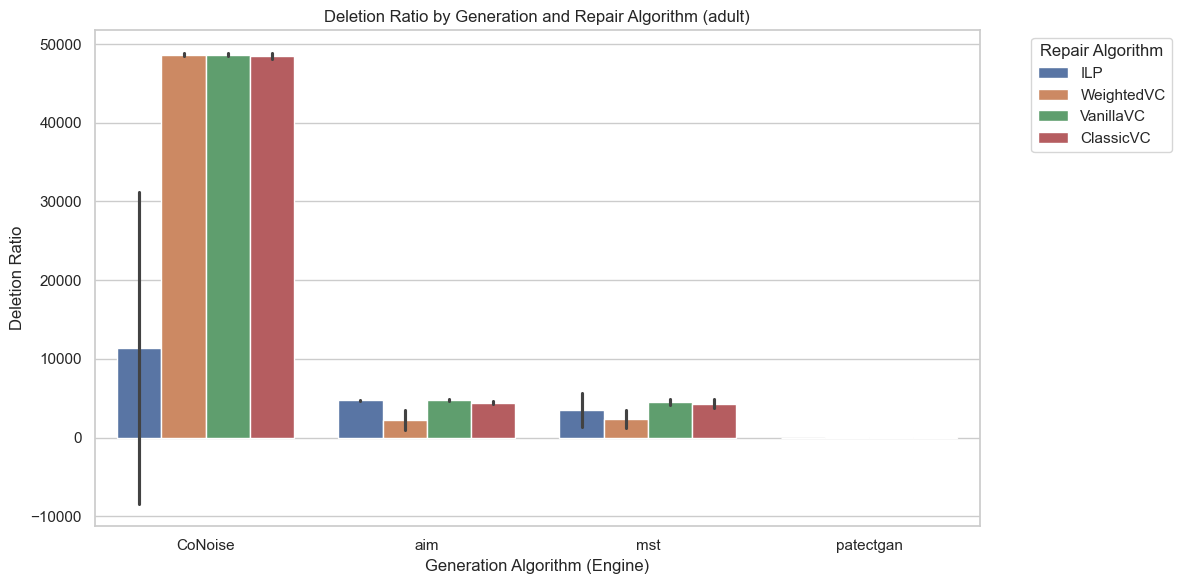


### Total Variation Distance (TVD)


engine,CoNoise,aim,mst,patectgan
repairer,,,,
ClassicVC,0.000943,0.161966,0.180051,0.933834
ILP,0.309794,0.159345,0.267586,0.500000
VanillaVC,0.000632,0.160600,0.176932,0.800421
WeightedVC,0.000709,0.234460,0.237917,0.762506


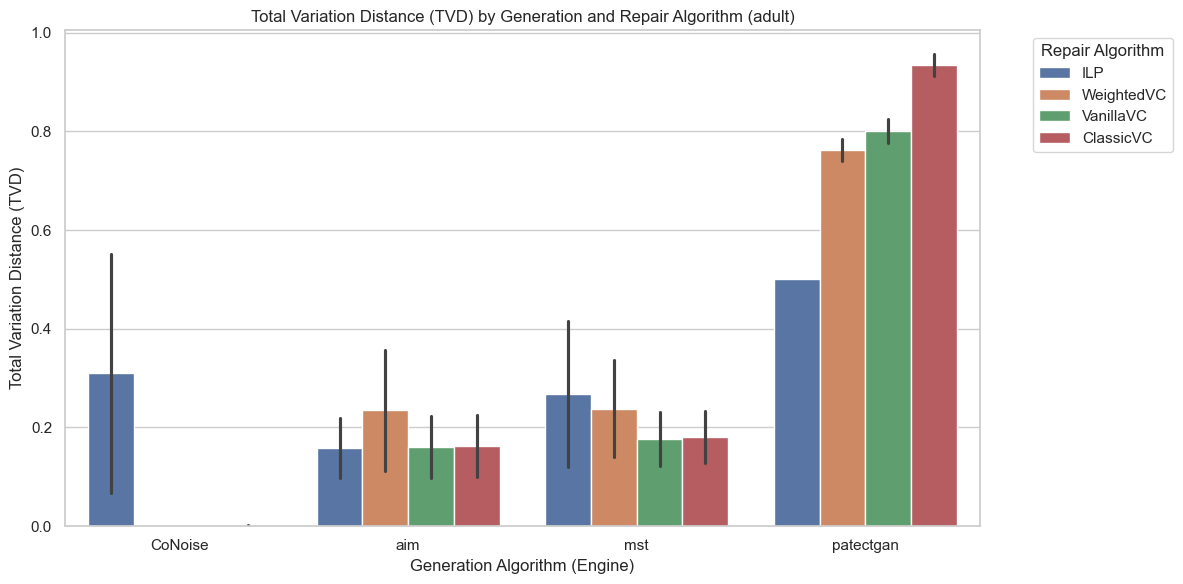


### Marginal Error


engine,CoNoise,aim,mst,patectgan
repairer,,,,
ClassicVC,0.484045,1.038559e+06,175562.408354,5.552477e+06
ILP,506588.149723,9.663961e+05,607978.558987,6.316793e+06
VanillaVC,0.484937,1.014839e+06,154536.250748,3.306851e+06
WeightedVC,0.435249,9.664401e+05,151093.905228,4.374126e+05


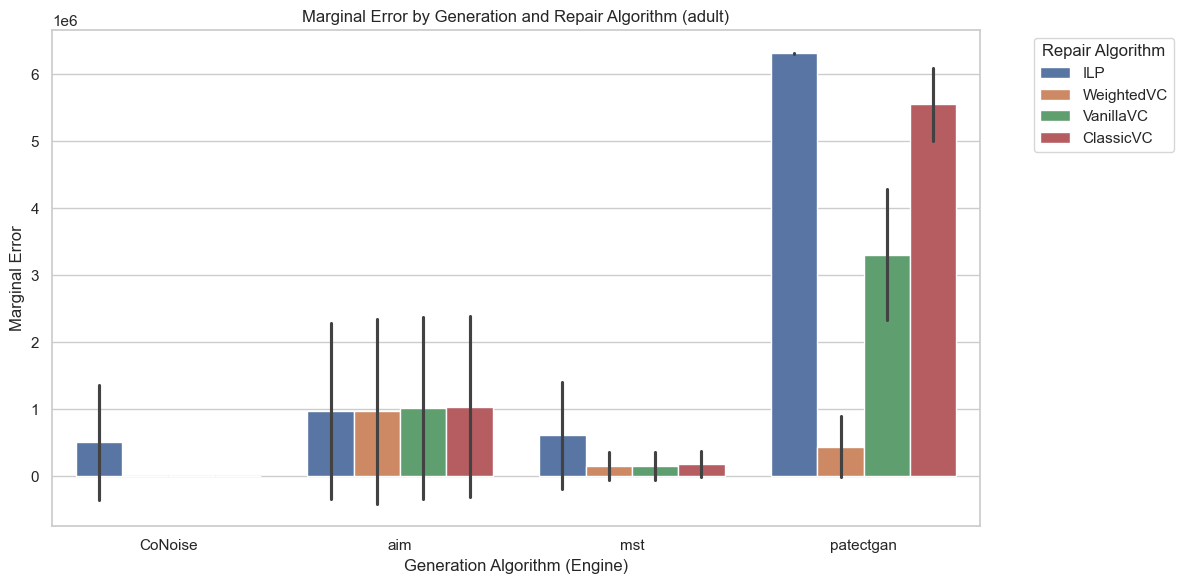


### Repair Runtime (seconds)


engine,CoNoise,aim,mst,patectgan
repairer,,,,
ClassicVC,97.247681,3.038397,5.551324,1761.626171
ILP,9844.046573,2412.504803,3969.970550,14969.383399
VanillaVC,36.092441,2.071287,3.306900,1166.106910
WeightedVC,58.942807,56.587242,55.306650,1351.979386


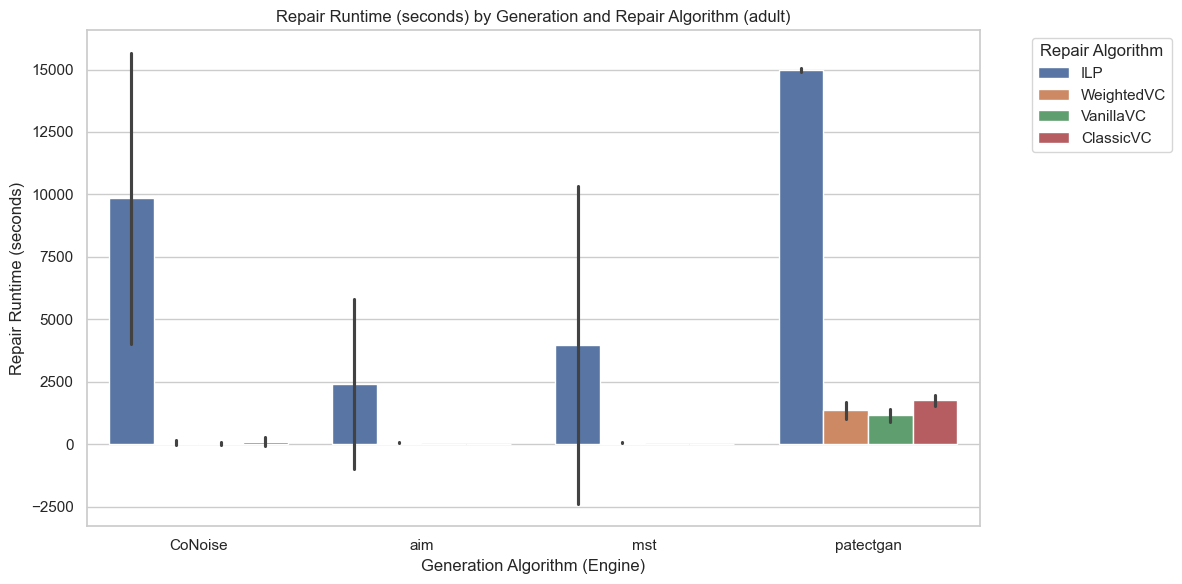

In [2]:
analyze_dataset('adult')

## Dataset: CENSUS


# Analysis for Dataset: CENSUS

### Deletion Ratio


engine,CoNoise,aim,mst,patectgan
repairer,,,,
ClassicVC,3.395326e+06,4324.000000,3930.666667,34.333333
ILP,5.580085e+05,3943.833333,3403.916667,102.900000
VanillaVC,3.395465e+06,4653.166667,4328.666667,505.000000
WeightedVC,3.395465e+06,4120.666667,3928.666667,102.500000


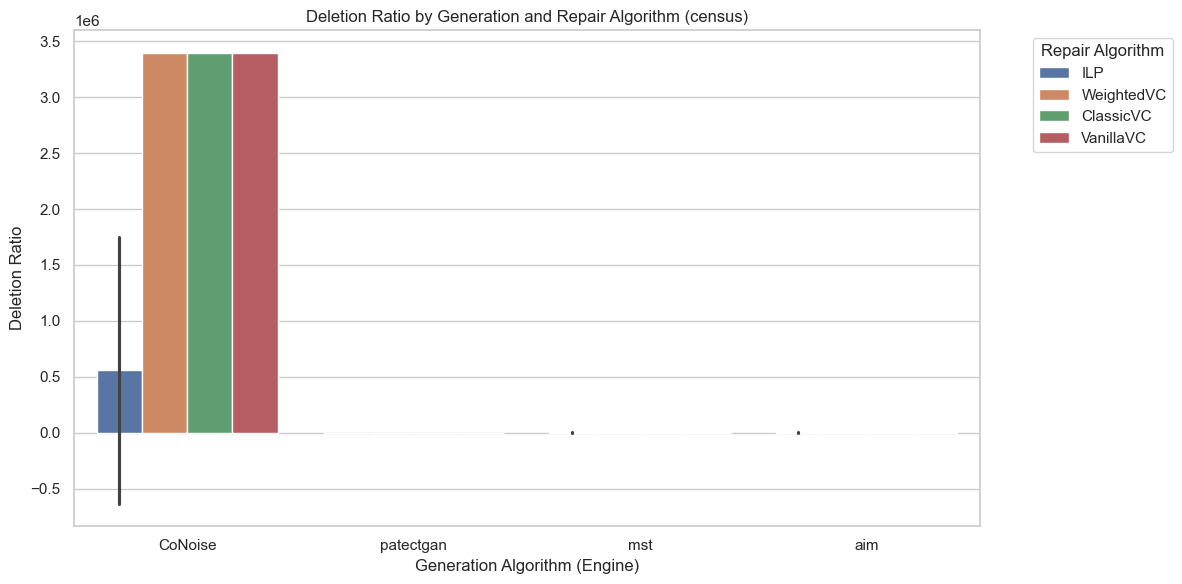


### Total Variation Distance (TVD)


engine,CoNoise,aim,mst,patectgan
repairer,,,,
ClassicVC,0.000027,0.110491,0.167052,0.786237
ILP,0.083007,0.163689,0.218318,0.530810
VanillaVC,0.000012,0.103765,0.143588,0.655442
WeightedVC,0.000012,0.116297,0.157762,0.552437


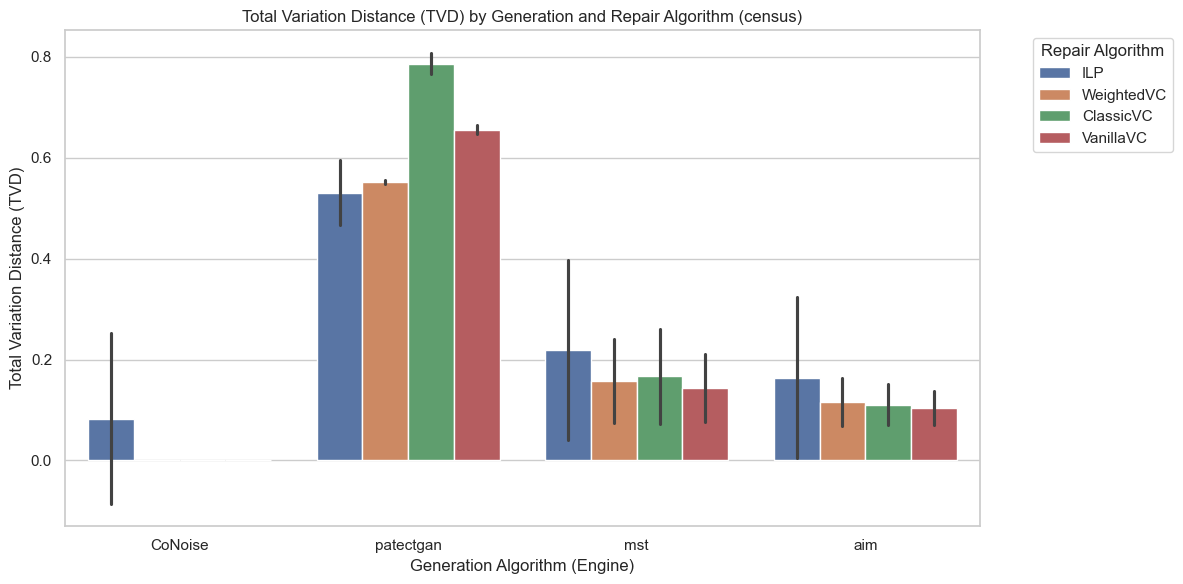


### Marginal Error


engine,CoNoise,aim,mst,patectgan
repairer,,,,
ClassicVC,0.059982,3996.673032,3684.771959,6.563761e+05
ILP,5005.234565,124792.317237,267018.870659,2.142210e+06
VanillaVC,0.059451,3585.224061,8304.061913,8.083980e+04
WeightedVC,0.059451,6098.409957,4860.422860,2.048502e+04


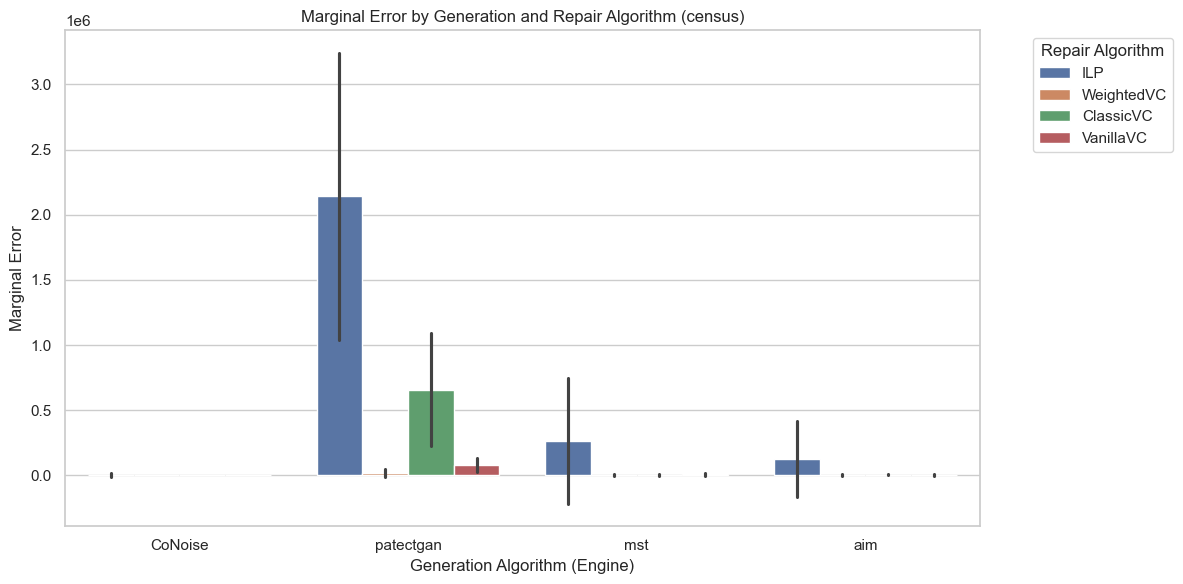


### Repair Runtime (seconds)


engine,CoNoise,aim,mst,patectgan
repairer,,,,
ClassicVC,379.382498,4.409561,4.185393,262.186847
ILP,3648.468431,3837.936631,4140.744302,13456.566829
VanillaVC,245.853909,3.381701,3.014897,160.180232
WeightedVC,445.932172,87.725694,58.603751,320.905591


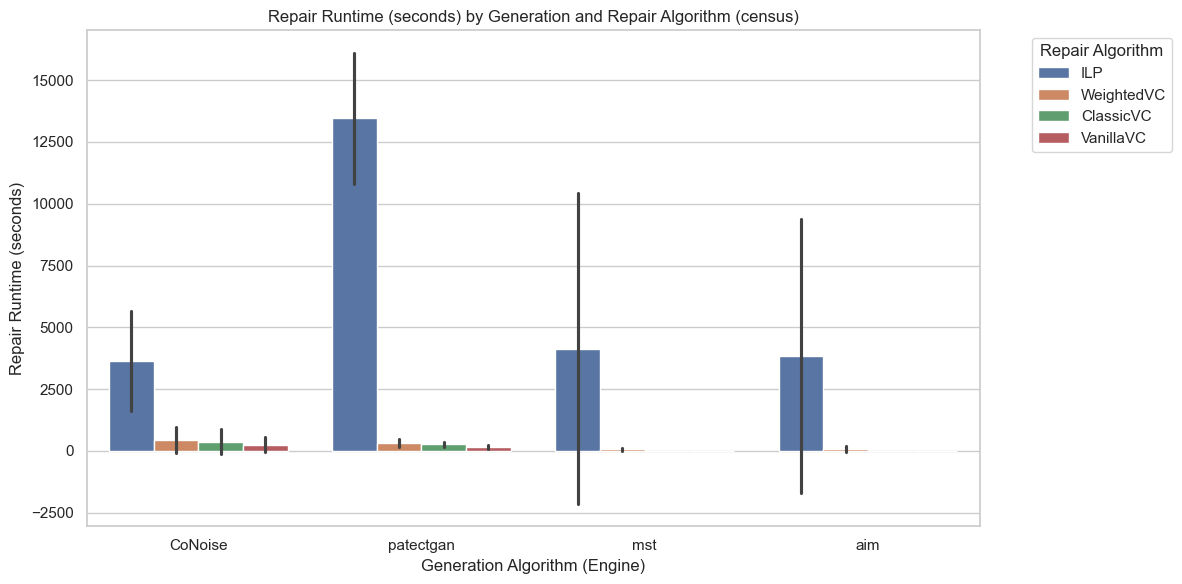

In [3]:
analyze_dataset('census')

## Dataset: COMPAS


# Analysis for Dataset: COMPAS

### Deletion Ratio


engine,CoNoise,aim,mst,patectgan
repairer,,,,
ClassicVC,60395.466667,4701.000000,4763.666667,1.333333
ILP,17136.903226,4847.333333,4897.750000,166.833333
VanillaVC,60595.933333,4818.000000,4857.500000,353.833333
WeightedVC,60494.733333,4122.333333,4189.166667,5.833333


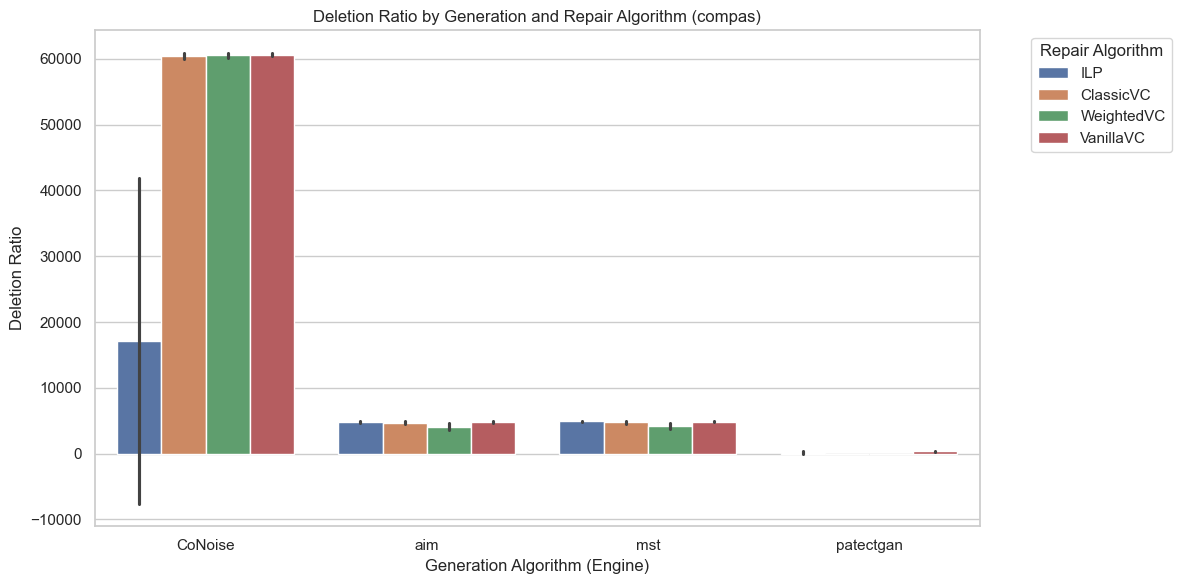


### Total Variation Distance (TVD)


engine,CoNoise,aim,mst,patectgan
repairer,,,,
ClassicVC,0.000413,0.038421,0.051312,0.717858
ILP,0.122540,0.036483,0.048777,0.524166
VanillaVC,0.000264,0.038059,0.049356,0.568635
WeightedVC,0.000541,0.057429,0.064365,0.516624


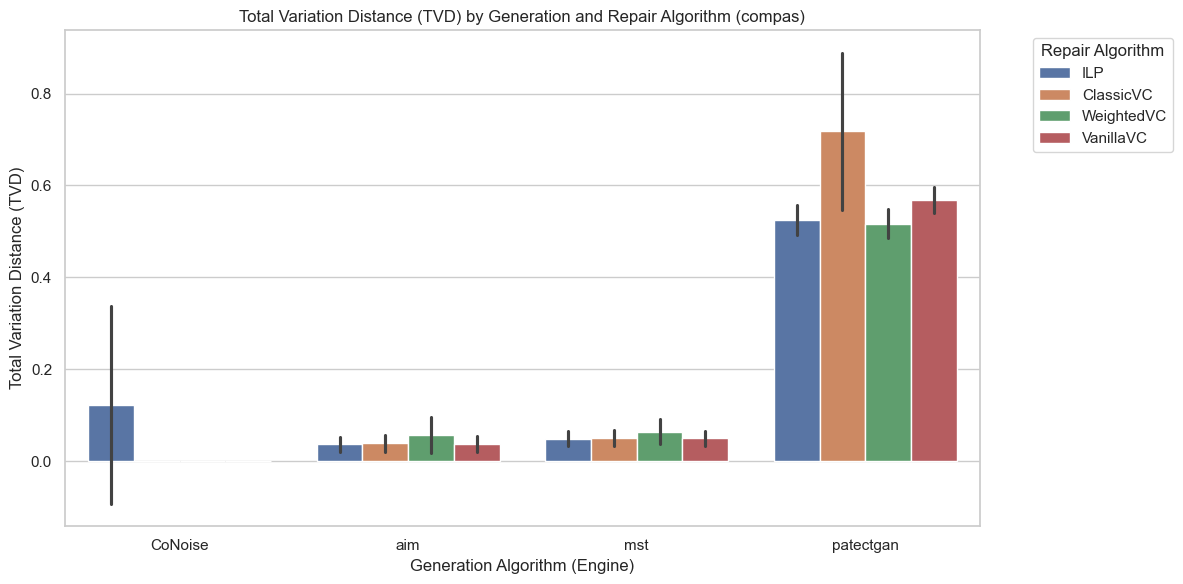


### Marginal Error


engine,CoNoise,aim,mst,patectgan
repairer,,,,
ClassicVC,0.161346,183573.963702,30.348336,5.530879e+06
ILP,388629.454273,112645.802783,31.808890,4.379142e+06
VanillaVC,0.159883,115715.833936,31.502635,5.295928e+04
WeightedVC,0.160422,86248.886564,25.172784,5.283265e+04


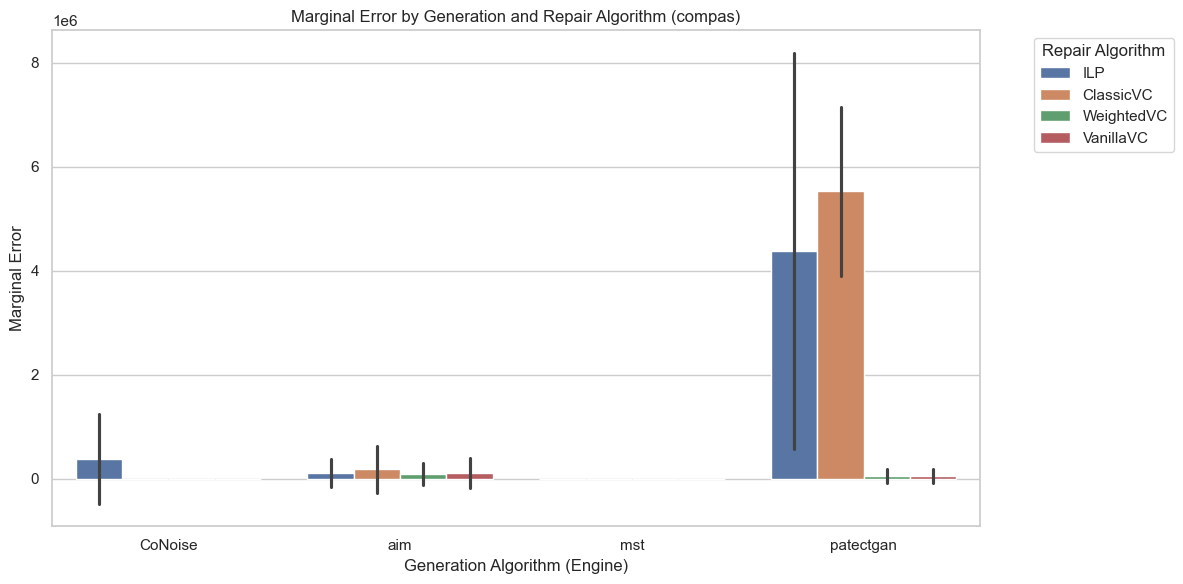


### Repair Runtime (seconds)


engine,CoNoise,aim,mst,patectgan
repairer,,,,
ClassicVC,201.322542,3.433703,1.883175,1961.720521
ILP,3092.982227,2208.245653,2350.444386,10951.524293
VanillaVC,97.633241,2.558883,1.457072,1585.881765
WeightedVC,189.272830,49.228450,82.706620,1989.827372


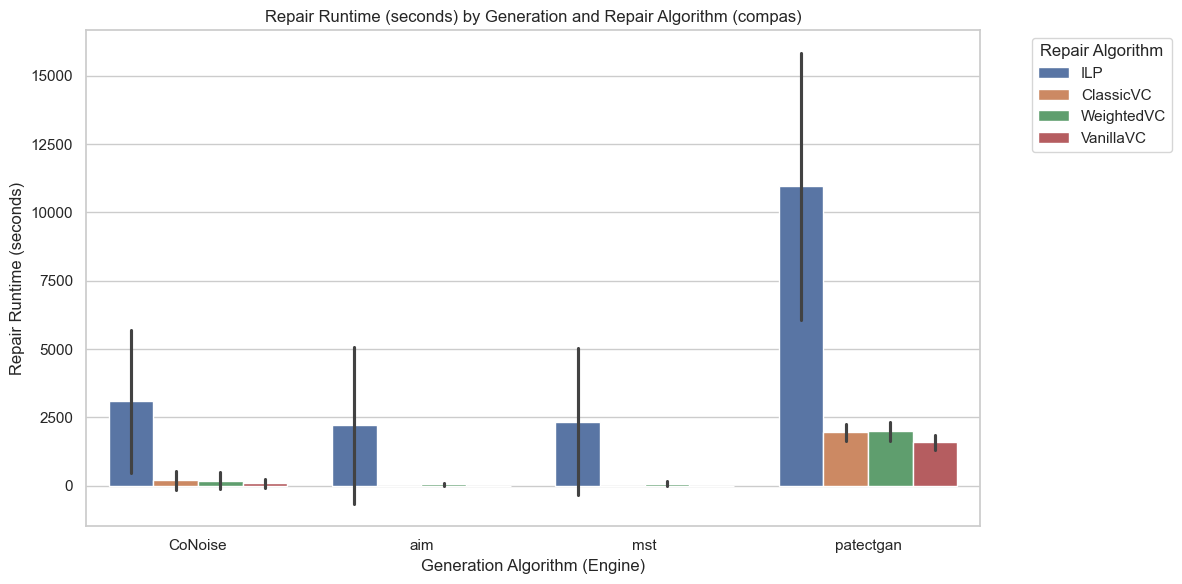

In [4]:
analyze_dataset('compas')

## Dataset: TAX


# Analysis for Dataset: TAX

### Deletion Ratio


engine,CoNoise,aim,mst,patectgan
repairer,,,,
ClassicVC,999459.466667,3792.000000,2536.666667,36.000000
ILP,248511.188679,2107.166667,1696.000000,83.833333
VanillaVC,999684.600000,4209.333333,3384.333333,110.666667
WeightedVC,999684.600000,4137.000000,3280.000000,97.333333


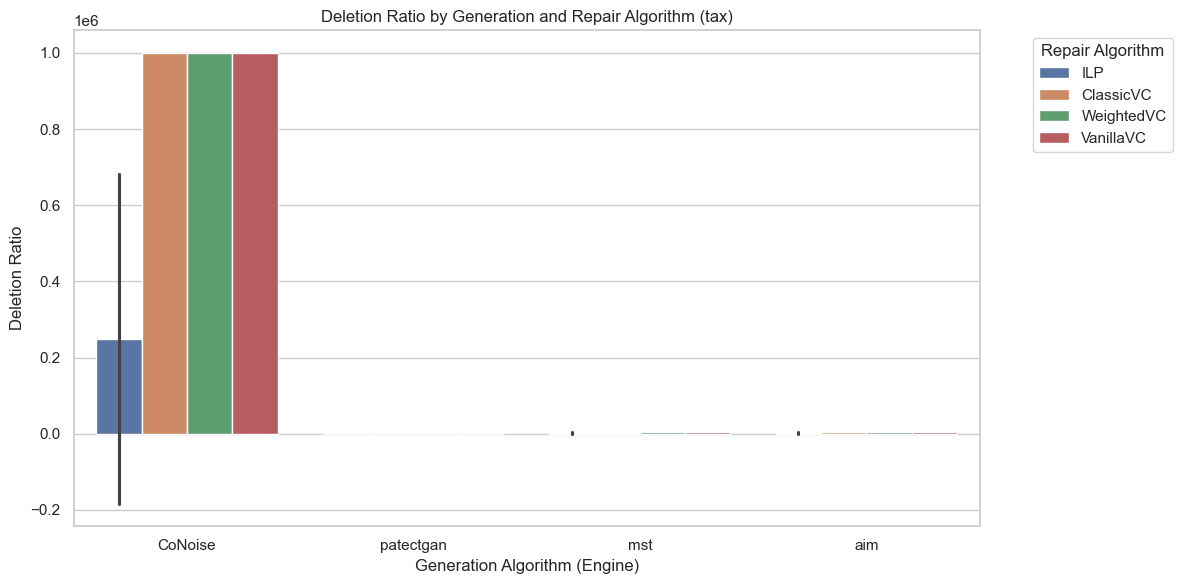


### Total Variation Distance (TVD)


engine,CoNoise,aim,mst,patectgan
repairer,,,,
ClassicVC,0.000082,0.118624,0.244331,0.784221
ILP,0.043384,0.296378,0.337455,0.573330
VanillaVC,0.000051,0.093722,0.174998,0.664828
WeightedVC,0.000051,0.094858,0.173676,0.520436


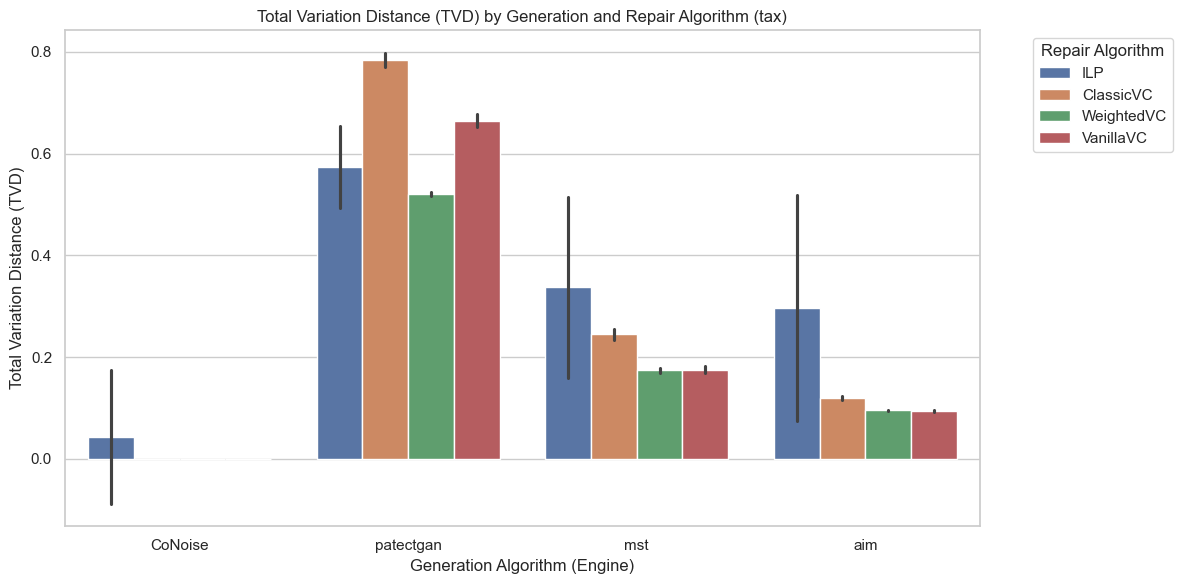


### Marginal Error


engine,CoNoise,aim,mst,patectgan
repairer,,,,
ClassicVC,0.011887,0.138755,8.466945e-01,1.746592e+06
ILP,99407.811125,934096.494451,1.100263e+06,1.978754e+06
VanillaVC,0.011899,0.203449,6.361006e-01,1.424160e+06
WeightedVC,0.011899,0.132008,6.008772e-01,1.145331e+05


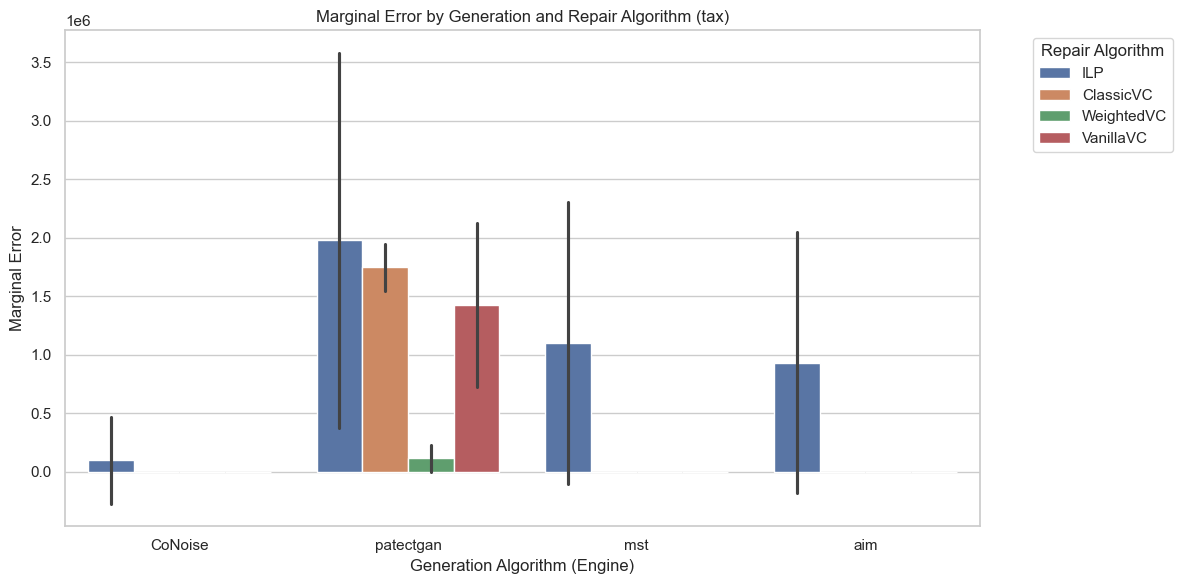


### Repair Runtime (seconds)


engine,CoNoise,aim,mst,patectgan
repairer,,,,
ClassicVC,428.257283,0.658618,2.933127,61.921862
ILP,2208.396824,7210.782478,7205.468360,7260.841175
VanillaVC,360.045055,0.847666,2.390271,64.274182
WeightedVC,690.819634,8.017865,19.882289,108.726206


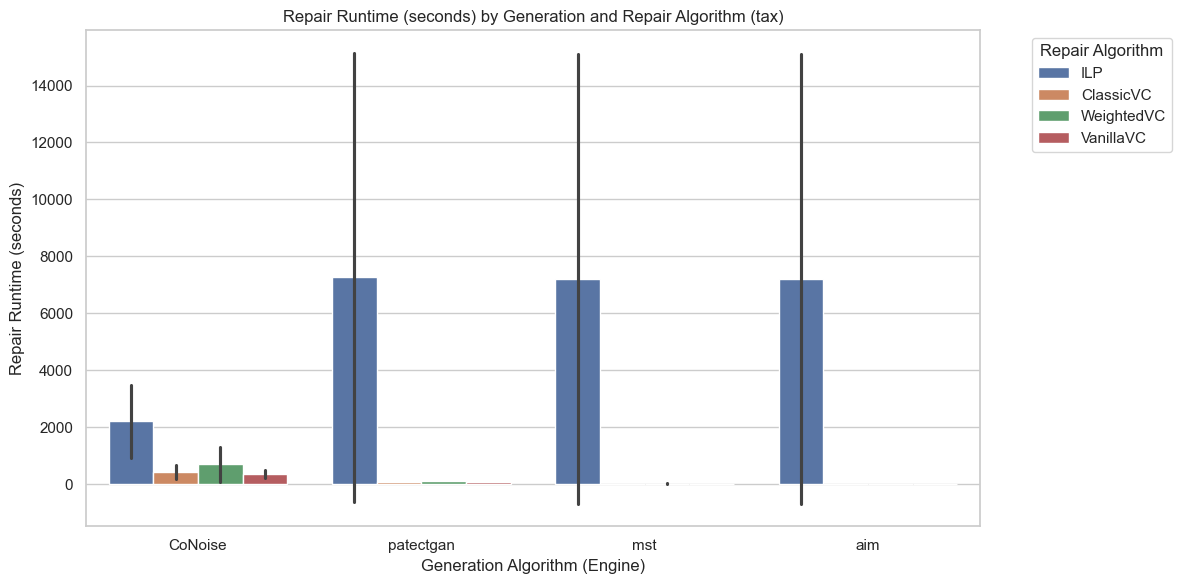

In [5]:
analyze_dataset('tax')